# Motorcars

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


## Laden

In [3]:
df = pd.read_csv('./mtcars.csv')

## Exploration

In [4]:
df.shape

(32, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


* Bedeutung der Spalten
  * model = Name
  * mpg = Miles per Gallon
  * cyl = Anzahl der Zylinder
  * displacement = Hubraum
  * hp = PS
  * drat = Achsenübersetzung
  * wt = Gewicht
  * qsec = "Quarter Mile Time"
  * vs = Motortyp, 0=V-Shaped, 1 = normal
  * am = Gangschaltung, 0=automatisch, 1=manuell
  * gear = Anzahl Gänge ohne Rückwärtsgang
  * carb = Anzahl der Vergaser (= carburetors)

* Ergebnis
  * Fast alles numerisch
  * Kandidaten Kategorien
    * cyl, vs, am und gear
    * Model

In [6]:
df['model'].nunique()

32

* model ist nicht sinnvoll kategorisierbar, hat ja soviele Werte wie der gesamte Datensatz

In [7]:
category_candidates = ('cyl', 'vs', 'am', 'gear', 'carb')
for column in category_candidates:
    print(f'{column} has {df[column].nunique()} values')


cyl has 3 values
vs has 2 values
am has 2 values
gear has 3 values
carb has 6 values


* Ergebnis
  * cyl, vs, am, gear, carb sind kategorisierbar
  

In [8]:
for column in category_candidates:
    df[column] = pd.Categorical(df[column])
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   model   32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     category
 11  carb    32 non-null     category
dtypes: category(5), float64(5), int64(1), object(1)
memory usage: 2.8+ KB


## Potenzielle Zusammenhänge

## PairGrid mit Scatterplot

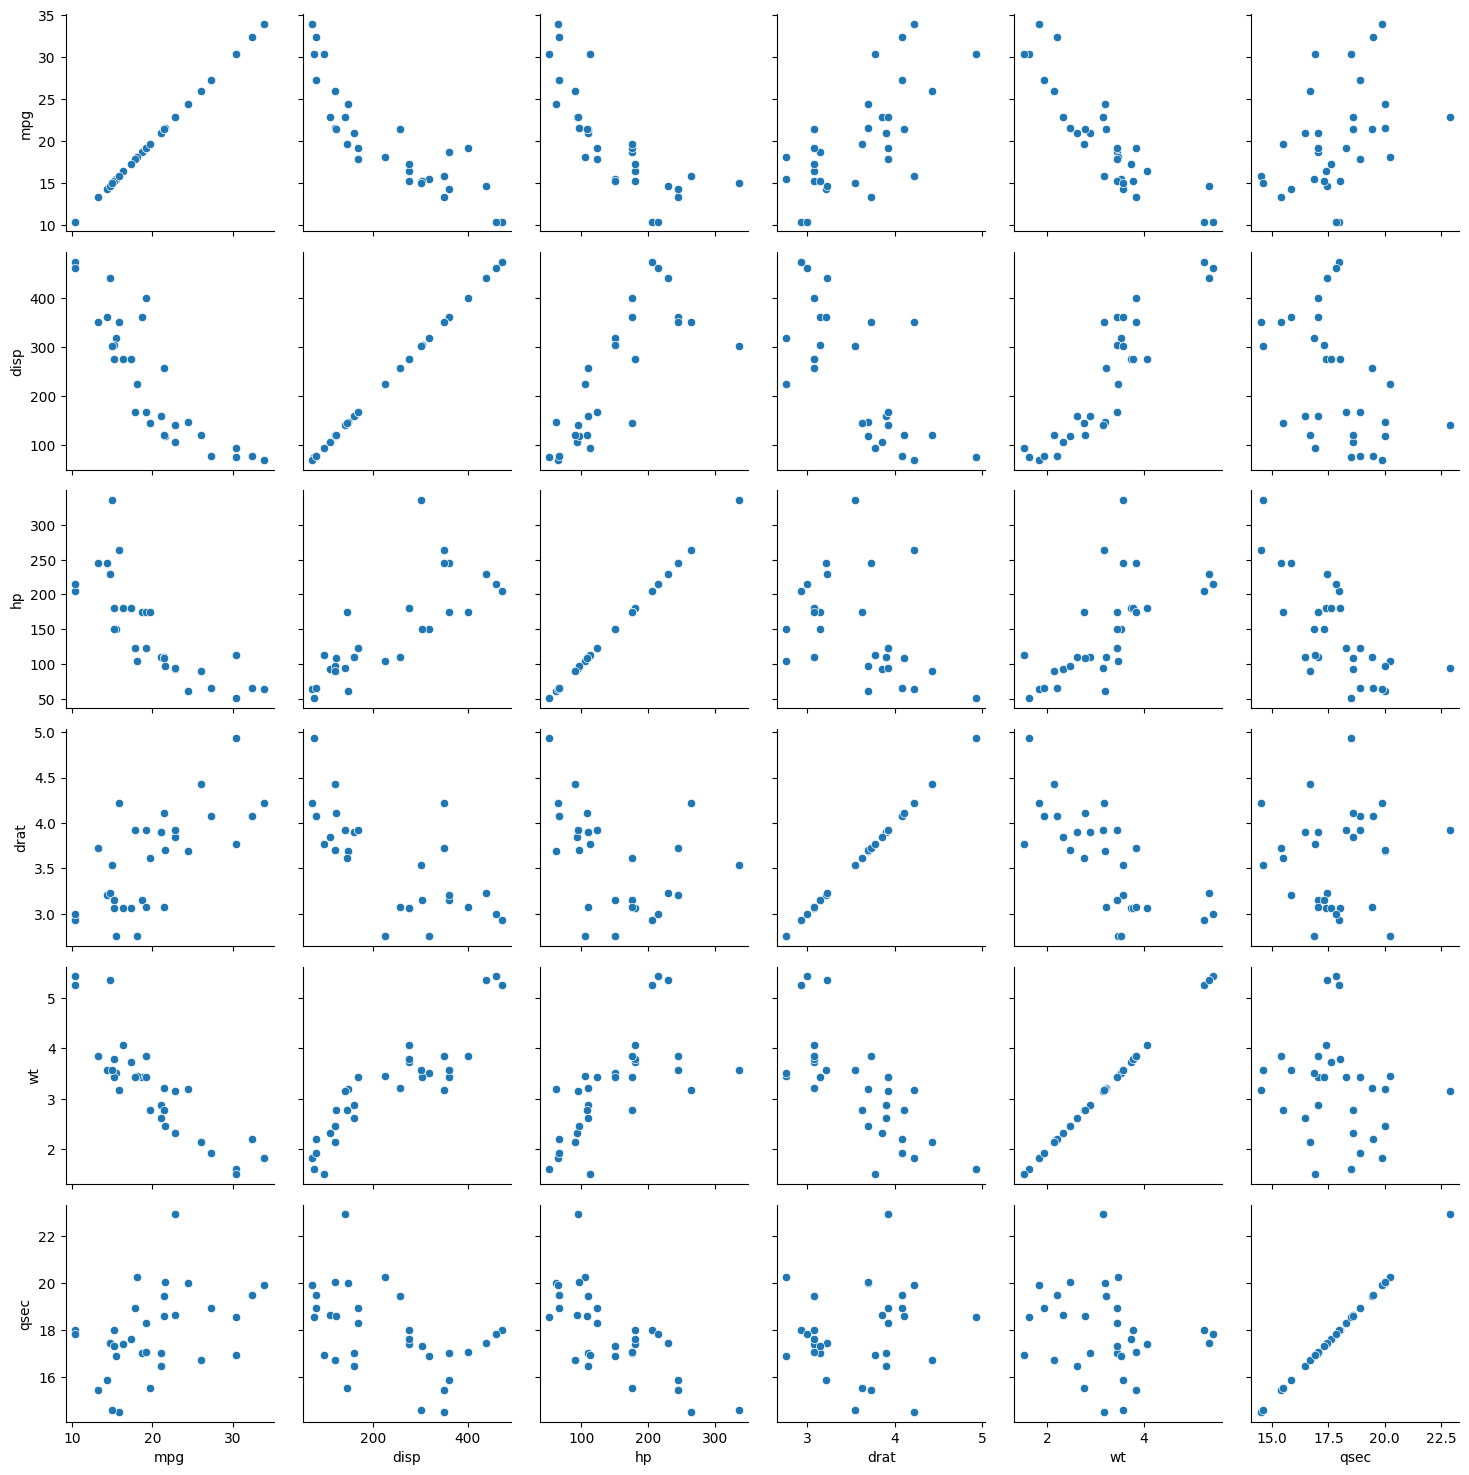

In [9]:
plots = sns.PairGrid(df)
plots.map(sns.scatterplot)

## Heatmap

<Axes: >

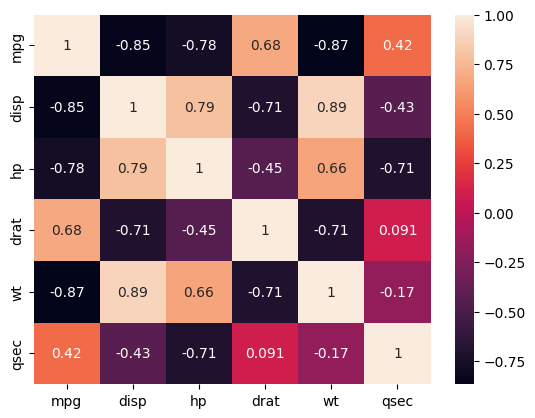

In [10]:
sns.heatmap(df[df.select_dtypes(include='number').columns].corr(), annot=True)

In [11]:
## Kategorien

<Axes: >

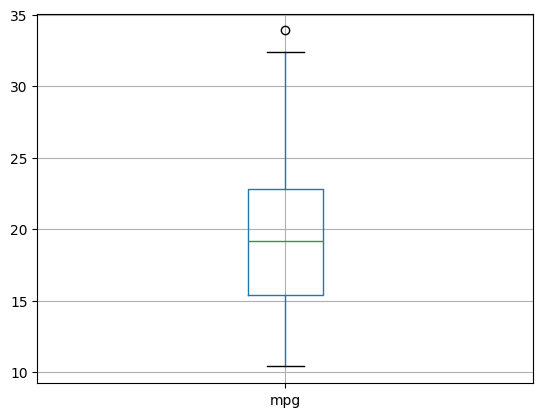

In [12]:
df.boxplot('mpg')

<Axes: title={'center': 'mpg'}, xlabel='am'>

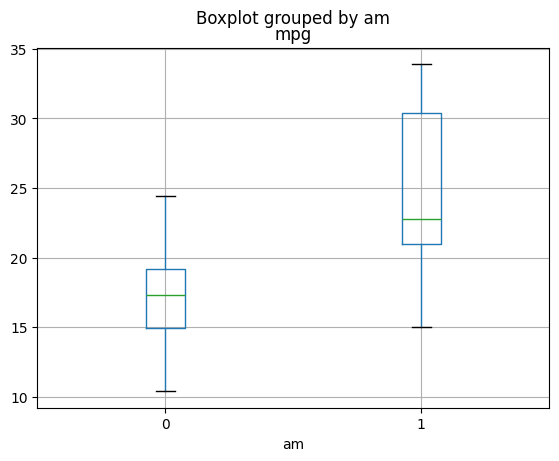

In [13]:
df.boxplot('mpg', by='am')

<Axes: title={'center': 'mpg'}, xlabel='cyl'>

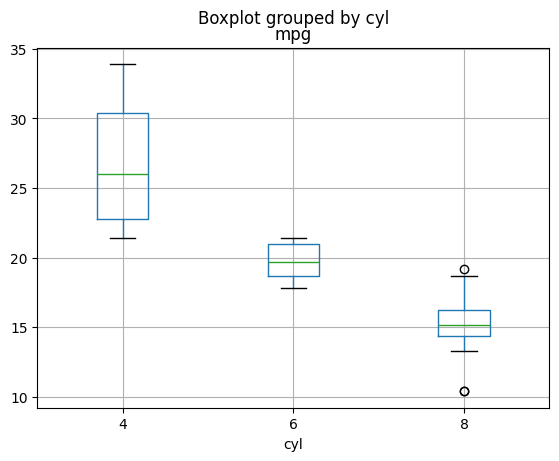

In [14]:
df.boxplot('mpg', by='cyl')

<Axes: title={'center': 'wt'}, xlabel='vs'>

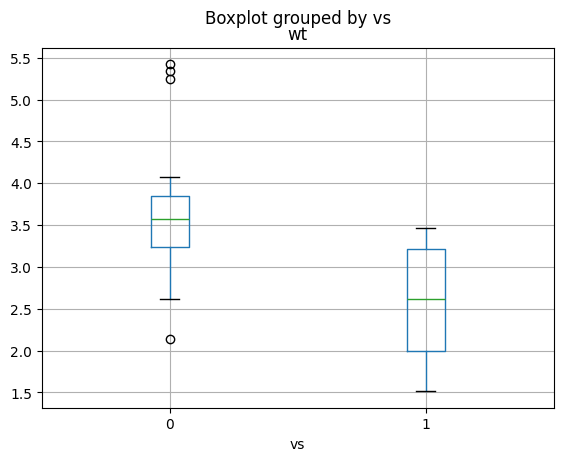

In [15]:
df.boxplot('wt', by='vs')

## Analyse

### Deskriptive Statistik

In [16]:
df.describe()

,mpg,disp,hp,drat,wt,qsec
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.090625,230.721875,146.687500,3.596563,3.217250,17.848750
std,6.026948,123.938694,68.562868,0.534679,0.978457,1.786943
min,10.400000,71.100000,52.000000,2.760000,1.513000,14.500000
25%,15.425000,120.825000,96.500000,3.080000,2.581250,16.892500
50%,19.200000,196.300000,123.000000,3.695000,3.325000,17.710000
75%,22.800000,326.000000,180.000000,3.920000,3.610000,18.900000
max,33.900000,472.000000,335.000000,4.930000,5.424000,22.900000


<Axes: ylabel='Density'>

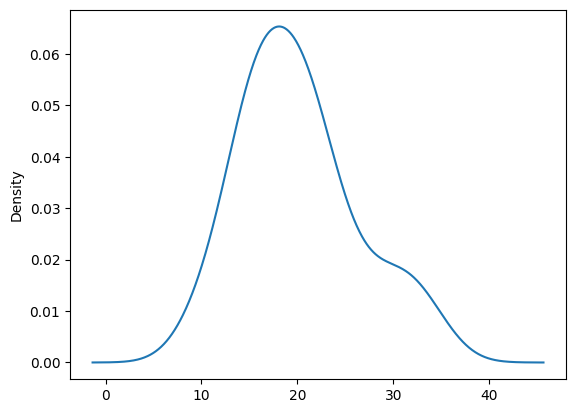

In [22]:
df['mpg'].plot(kind='density')

In [18]:
f'Kurtosis: {df["mpg"].kurt():.4}'

'Kurtosis: -0.02201'

In [20]:
f'Skewness: {df["mpg"].skew():.4}'

'Skewness: 0.6724'

### Regressionsanalyse

* Dazu wird das SkiKit_Modul
    * pip install scikit-learn
    * pip install --break-system-packages scikit-learn
    * pip3 install --break-system-packages scikit-learn
    * .../python.exe -m pip install --break-system-packages scikit-learn


<Axes: xlabel='wt', ylabel='mpg'>

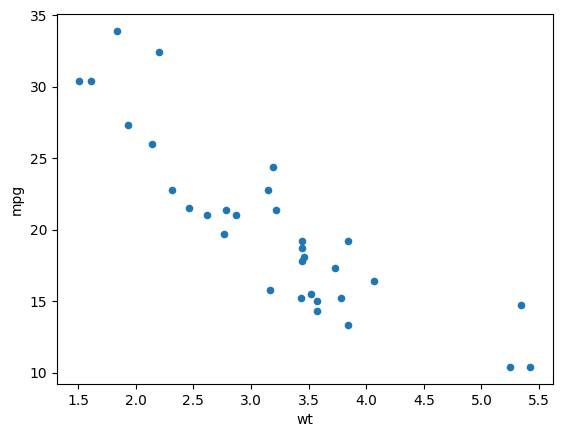

In [23]:
df.plot(kind='scatter', x='wt', y='mpg')

In [26]:
from sklearn import linear_model

regression_model = linear_model.LinearRegression()
regression_model.fit(X=pd.DataFrame(df['wt']), y=df['mpg'])
print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
print(f'Steigung: {regression_model.coef_[0]:.2f}')

Achsenabschnitt: 37.29
Steigung: -5.34


In [27]:
regression_model.score(X=pd.DataFrame(df['wt']), y=df['mpg'])

0.7528327936582646

In [29]:
predicted_mpg = regression_model.predict(X=pd.DataFrame(df['wt']))
predicted_mpg

array([23.28261065, 21.9197704 , 24.88595212, 20.10265006, 18.90014396,
       18.79325453, 18.20536265, 20.23626185, 20.45004071, 18.90014396,
       18.90014396, 15.53312687, 17.3502472 , 17.08302362,  9.22665041,
        8.29671236,  8.71892561, 25.52728871, 28.65380458, 27.47802083,
       24.11100374, 18.47258623, 18.92686632, 16.76235533, 16.73563297,
       26.94357367, 25.847957  , 29.19894068, 20.34315128, 22.48093991,
       18.20536265, 22.4274952 ])

In [30]:
residuals = df['mpg'] - predicted_mpg
residuals.describe()

count    3.200000e+01
mean    -8.215650e-15
std      2.996352e+00
min     -4.543151e+00
25%     -2.364709e+00
50%     -1.251956e-01
75%      1.409561e+00
max      6.872711e+00
Name: mpg, dtype: float64

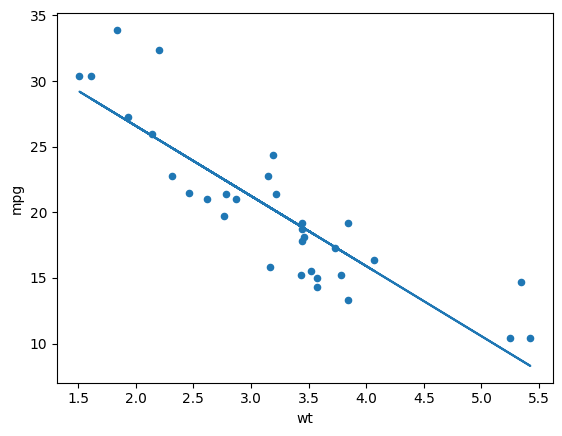

In [32]:
df.plot(kind='scatter', x='wt', y='mpg')
plt.plot(df['wt'].to_numpy(), predicted_mpg)

### Probability Plot

((array([-2.02511189, -1.62590278, -1.38593914, -1.20666642, -1.05953591,
         -0.93235918, -0.81872017, -0.71478609, -0.6180591 , -0.52680137,
         -0.43973827, -0.35589149, -0.27447843, -0.19484777, -0.11643566,
         -0.03873405,  0.03873405,  0.11643566,  0.19484777,  0.27447843,
          0.35589149,  0.43973827,  0.52680137,  0.6180591 ,  0.71478609,
          0.81872017,  0.93235918,  1.05953591,  1.20666642,  1.38593914,
          1.62590278,  2.02511189]),
  array([-4.54315128, -3.90536265, -3.72686632, -3.46235533, -3.20536265,
         -2.97258623, -2.78093991, -2.61100374, -2.28261065, -2.08595212,
         -1.88302362, -1.10014396, -1.0274952 , -0.9197704 , -0.69325453,
         -0.20014396, -0.0502472 ,  0.152043  ,  0.29985604,  0.35642633,
          0.86687313,  1.17334959,  1.20105932,  1.29734994,  1.74619542,
          2.10328764,  2.34995929,  2.46436703,  4.16373815,  5.98107439,
          6.42197917,  6.87271129])),
 (np.float64(3.0327797489458974),
  n

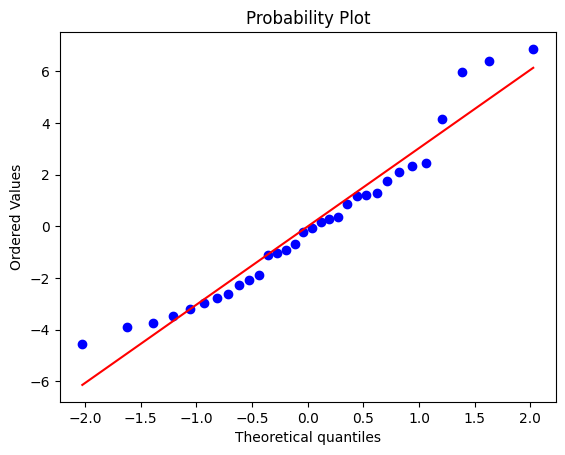

In [33]:
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=plt)

## Effekte 2. Ordnung

In [42]:
regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([df['wt'], df['wt']**2]).T
regression_model.fit(X=x_axis, y=df['mpg'])
print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
print(f'Koeffizienten: {regression_model.coef_}')
print(f'Score: {regression_model.score(X=x_axis, y=df['mpg']):.2f}')

Achsenabschnitt: 49.93
Koeffizienten: [-13.38033708   1.17108689]
Score: 0.82


c:\Users\raine\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


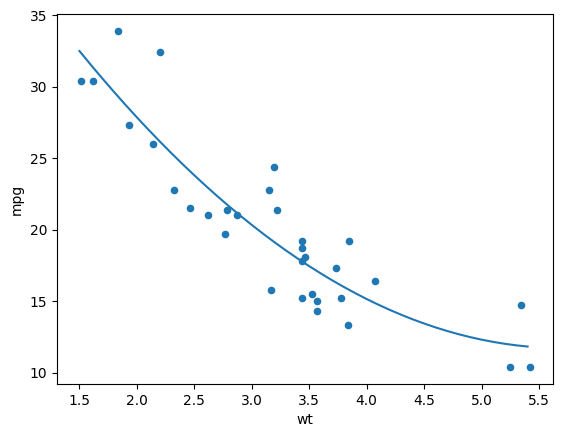

In [44]:
df.plot(kind='scatter', x='wt', y='mpg')
poly_range = np.arange(1.5, 5.5, 0.1)
predicted = regression_model.predict(pd.DataFrame([poly_range, poly_range**2]).T)
plt.plot(poly_range, predicted)

## Multiple lineare Regression 

In [49]:
multi_regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([
    df['wt'],
    df['disp'],
    df['wt']**2,
    df['disp']**2
]).T
multi_regression_model.fit(X=x_axis, y=df['mpg'])
print(f'Achsenabschnitt: {multi_regression_model.intercept_:.2f}')
print(f'Koeffizienten: {multi_regression_model.coef_}')
print(f'Score: {multi_regression_model.score(X=x_axis, y=df['mpg']):.2f}')



Achsenabschnitt: 42.92
Koeffizienten: [-5.05865794e+00 -7.15368037e-02  2.39855024e-01  1.06331542e-04]
Score: 0.86


In [48]:
multi_regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([
    df['wt'],
    df['disp'],
    df['hp'],
    df['wt']**2,
    df['disp']**2,
    df['hp']**2
]).T
multi_regression_model.fit(X=x_axis, y=df['mpg'])
print(f'Achsenabschnitt: {multi_regression_model.intercept_:.2f}')
print(f'Koeffizienten: {multi_regression_model.coef_}')
print(f'Score: {multi_regression_model.score(X=x_axis, y=df['mpg']):.2f}')



Achsenabschnitt: 47.49
Koeffizienten: [-6.73465885e+00 -2.27349753e-02 -8.96805226e-02  4.70037262e-01
  4.52472872e-05  1.64464911e-04]
Score: 0.89


### Effekte dritter und höherer Ordnung

In [53]:
useless_regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([
    df['wt'], 
    df['wt']**2,
    df['wt']**3,
    df['wt']**4,
    df['wt']**5,
    df['wt']**6,
    df['wt']**7,
    df['wt']**8,
    df['wt']**9,
    df['wt']**10
    ]).T
useless_regression_model.fit(X=x_axis, y=df['mpg'])
print(f'Achsenabschnitt: {useless_regression_model.intercept_:.2f}')
print(f'Koeffizienten: {useless_regression_model.coef_}')
print(f'Score: {useless_regression_model.score(X=x_axis, y=df['mpg']):.2f}')

Achsenabschnitt: -14921.12
Koeffizienten: [ 6.45813559e+04 -1.20086130e+05  1.26931928e+05 -8.46598453e+04
  3.73155198e+04 -1.10334755e+04  2.16590404e+03 -2.70730544e+02
  1.94974162e+01 -6.15515436e-01]
Score: 0.87


c:\Users\raine\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


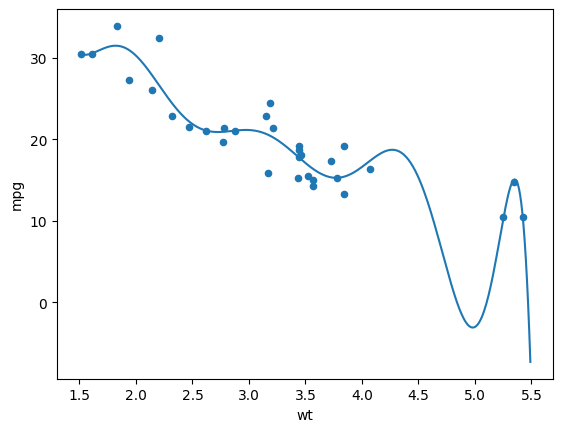

In [55]:
df.plot(kind='scatter', x='wt', y='mpg')
poly_range = np.arange(1.5, 5.5, 0.01)
x_axis = pd.DataFrame([
    poly_range, 
    poly_range**2,
    poly_range**3,
    poly_range**4,
    poly_range**5,
    poly_range**6,
    poly_range**7,
    poly_range**8,
    poly_range**9,
    poly_range**10
    ]).T

useless_prediction = useless_regression_model.predict(x_axis)

plt.plot(poly_range, useless_prediction)